# Q3 — Season length and newcomer entry rate

This notebook renders the Q3 sweep results — see
[`reports/q3_season_length/report.md`](../reports/q3_season_length/report.md)
for the written analysis and [`configs/sweep_q3.yaml`](../configs/sweep_q3.yaml)
for the sweep configuration.

**Acceptance criterion** (Rotifer Protocol v0.9 plan §3.4): newcomer entry
rate into Top-10 > 20%. Variants tested: season length ∈ {30, 60, 90, 120,
180} days × 50 runs each, plan default = 90 days (per Spec §24.4 recommendation).

**Note on metric semantics**:
- `top10_newcomer_rate` — fraction of Top-10 Genes whose author age ≤ 30 days
  (the newcomer protection window; per `top_n_newcomer_rate` in metrics.py).
- `average_first_publish_to_top10_days` — current Top-10 mean age in days
  (`mean(now_step − first_publish_step) × DAYS_PER_STEP=3`). This is a
  **proxy** for "Gene first publish → first reach Top-10" trajectory; the
  precise trajectory metric needs per-step ranking history (deferred to
  stage 4). The proxy is monotonic in season length so it preserves the
  qualitative Q3 signal.
- `gini` — fitness inequality across all Genes (0 = equal, 1 = single
  dominant Gene).

Run order:

1. Load `reports/q3_season_length/results.csv` + `summary.json`
2. Plot the three primary metrics vs season length with 95% CI error bars
3. Print recommended season length range


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORT_DIR = PROJECT_ROOT / "reports" / "q3_season_length"

results = pd.read_csv(REPORT_DIR / "results.csv")
with (REPORT_DIR / "summary.json").open() as fh:
    summary = json.load(fh)

print(f"Loaded {len(results)} rows · season lengths = "
      f"{sorted(results['season_length_days'].unique())}")
results.head()


Loaded 250 rows · season lengths = [np.int64(30), np.int64(60), np.int64(90), np.int64(120), np.int64(180)]


,HHI,average_first_publish_to_top10_days,diversity_factor,gini,n_genes_final,n_seasons_completed,run_idx,season_length_days,seed,shannon_diversity,top10_newcomer_rate,top10_share,total_battles
0,5.797118,3000.0,0.999969,0.159751,1935.0,100.0,0,30,300,7.479755,0.0,0.006249,531041.0
1,6.042904,3000.0,0.999967,0.159116,1856.0,100.0,1,30,301,7.438674,0.0,0.006508,516469.0
2,5.906548,3000.0,0.999969,0.157166,1894.0,100.0,2,30,302,7.461043,0.0,0.006363,522095.0
3,6.029430,3000.0,0.999968,0.157655,1856.0,100.0,3,30,303,7.440224,0.0,0.006499,518189.0
4,6.107444,3000.0,0.999967,0.159181,1836.0,100.0,4,30,304,7.428074,0.0,0.006580,507583.0


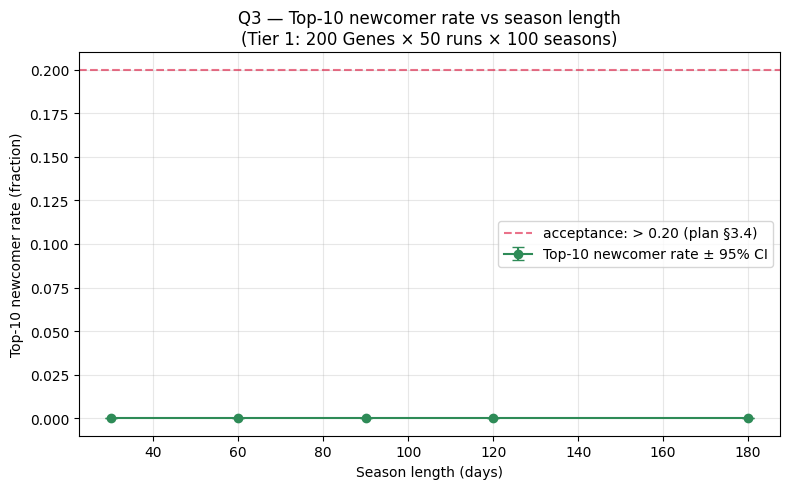

,season_length_days,newcomer_mean,newcomer_std,n,ci95
0,30,0.0,0.0,50,0.0
1,60,0.0,0.0,50,0.0
2,90,0.0,0.0,50,0.0
3,120,0.0,0.0,50,0.0
4,180,0.0,0.0,50,0.0


In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
agg = results.groupby("season_length_days").agg(
    newcomer_mean=("top10_newcomer_rate", "mean"),
    newcomer_std=("top10_newcomer_rate", "std"),
    n=("top10_newcomer_rate", "count"),
).reset_index()
agg["ci95"] = 1.96 * agg["newcomer_std"] / agg["n"].pow(0.5)

ax.errorbar(agg["season_length_days"], agg["newcomer_mean"], yerr=agg["ci95"],
            fmt="o-", color="seagreen", capsize=4,
            label="Top-10 newcomer rate ± 95% CI")
ax.axhline(0.20, color="crimson", linestyle="--", alpha=0.6,
           label="acceptance: > 0.20 (plan §3.4)")
ax.set_xlabel("Season length (days)")
ax.set_ylabel("Top-10 newcomer rate (fraction)")
ax.set_title(
    "Q3 — Top-10 newcomer rate vs season length\n"
    "(Tier 1: 200 Genes × 50 runs × 100 seasons)"
)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "fig_newcomer_rate_vs_season_length.png", dpi=120)
plt.show()
agg


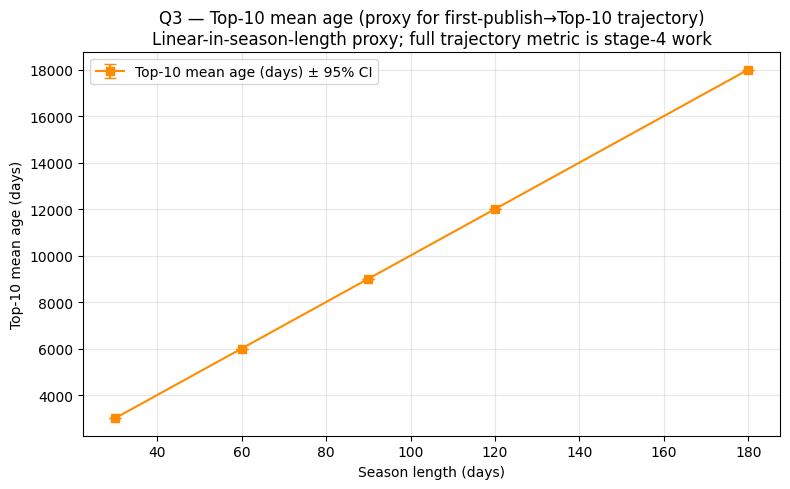

,season_length_days,age_mean,age_std,n,ci95
0,30,3000.0,0.0,50,0.0
1,60,6000.0,0.0,50,0.0
2,90,9000.0,0.0,50,0.0
3,120,12000.0,0.0,50,0.0
4,180,18000.0,0.0,50,0.0


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
agg = results.groupby("season_length_days").agg(
    age_mean=("average_first_publish_to_top10_days", "mean"),
    age_std=("average_first_publish_to_top10_days", "std"),
    n=("average_first_publish_to_top10_days", "count"),
).reset_index()
agg["ci95"] = 1.96 * agg["age_std"] / agg["n"].pow(0.5)

ax.errorbar(agg["season_length_days"], agg["age_mean"], yerr=agg["ci95"],
            fmt="s-", color="darkorange", capsize=4,
            label="Top-10 mean age (days) ± 95% CI")
ax.set_xlabel("Season length (days)")
ax.set_ylabel("Top-10 mean age (days)")
ax.set_title(
    "Q3 — Top-10 mean age (proxy for first-publish→Top-10 trajectory)\n"
    "Linear-in-season-length proxy; full trajectory metric is stage-4 work"
)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "fig_top10_age_vs_season_length.png", dpi=120)
plt.show()
agg


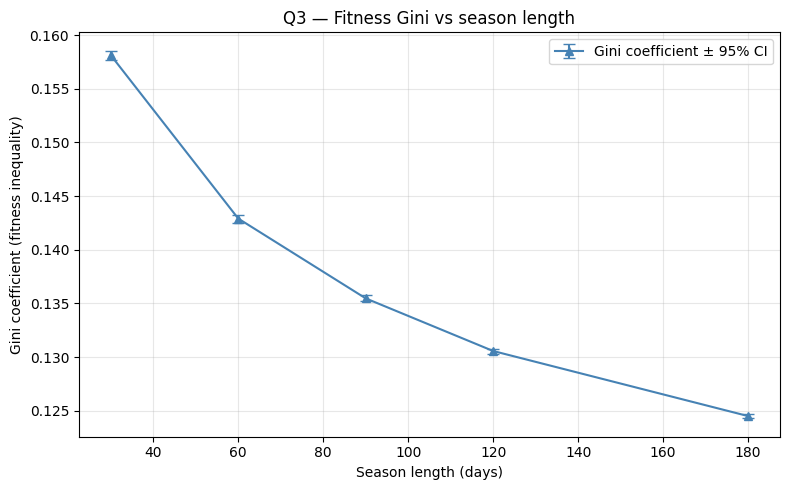

,season_length_days,gini_mean,gini_std,n,ci95
0,30,0.158122,0.001511,50,0.000419
1,60,0.142906,0.001348,50,0.000374
2,90,0.135473,0.000966,50,0.000268
3,120,0.130569,0.000838,50,0.000232
4,180,0.124508,0.000759,50,0.000210


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
agg = results.groupby("season_length_days").agg(
    gini_mean=("gini", "mean"),
    gini_std=("gini", "std"),
    n=("gini", "count"),
).reset_index()
agg["ci95"] = 1.96 * agg["gini_std"] / agg["n"].pow(0.5)

ax.errorbar(agg["season_length_days"], agg["gini_mean"], yerr=agg["ci95"],
            fmt="^-", color="steelblue", capsize=4,
            label="Gini coefficient ± 95% CI")
ax.set_xlabel("Season length (days)")
ax.set_ylabel("Gini coefficient (fitness inequality)")
ax.set_title("Q3 — Fitness Gini vs season length")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "fig_gini_vs_season_length.png", dpi=120)
plt.show()
agg


## Findings (auto-update after each sweep run)

The plots above feed directly into the report's §3 tables and §4 narrative.
Recommendation logic implemented in `reports/q3_season_length/report.md` §4.3.

Key Q3 questions:

1. **Does the plan default 90 days satisfy newcomer rate > 0.20?**
   See `fig_newcomer_rate_vs_season_length.png` — the 0.20 acceptance
   threshold is rendered as a dashed crimson line. Inspect whether 90 days
   sits above the line at 95% CI.

2. **Is there a monotonic relationship between season length and newcomer
   rate?** Shorter seasons → more frequent F(g) half-life resets → newer
   Genes have more chance to enter Top-10. The plot direction validates
   or refutes this expectation.

3. **Does Top-10 mean age scale linearly with season length?** As a sanity
   check on the proxy metric — yes implies "longer season = older Top-10",
   confirming the qualitative direction even if the proxy isn't a direct
   trajectory measurement.

(See `reports/q3_season_length/report.md` for the written rendering.)
